In [22]:
%load_ext autoreload
%autoreload 2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import dimorph_processing as dp
import gseapy as gp
import scanpy as sc
import json 
import time
from gseapy import barplot, dotplot, heatmap

import run_gseapy as rg
gp.__version__



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


'1.1.6'

# Gene Set Enrichment Analysis with GSEApy

load in data

In [3]:
metadata_df = pd.read_json('/bigdata/isaac/gaba_glut_NN_combined_metadata_full_name.json')

In [4]:
metadata_df.head()

,CTCGAGGCATCCGTTC-1_10X52_3,GTCCTCACACGACCTG-1_10X52_2,GGCTTGGGTCGGTACC-1_10X52_2,GGGAGTATCAGACCTA-1_10X52_3,CGTGCTTTCAAAGAAC-1_10X51_2,CGCAGGTTCGGTTAGT-1_10X52_1,CTACGGGCAGTCTCTC-1_10X51_2,AGGAGGTTCATTTGGG-1_10X35_1,ATCAGGTCACGAAGAC-1_10X36_2,CAAGGGAGTTCCACAA-1_10X38_2,...,AGGAATATCTACTTCA-1_10X52_2,CATCGTCCAAGTGGGT-1_10X52_2,ATAGGCTAGTCTGGTT-1_10X38_2,GTTACCCAGTAATCCC-1_10X36_1,AGTGATCCAGTCACGC-1_10X52_2,ACACCAAAGCGTCTGC-1_10X51_4,AATCGACGTCATAACC-1_10X37_1,GAGGGATAGAACTTCC-1_10X52_2,TGCGGCATCAAAGAAC-1_10X52_2,ATCCACCCAATTTCGG-1_10X51_3
Serial_Number,103.0,102.0,102.0,103.0,98.0,101.0,98.0,63.0,66.0,70.0,...,102.0,102.0,70.0,65.0,102.0,100.0,67.0,102.0,102.0,99.0
Date_Captured,05/31/20,05/31/20,05/31/20,05/31/20,05/31/20,05/31/20,05/31/20,2019-11-20,2019-11-24,2019-12-01,...,05/31/20,05/31/20,2019-12-01,2019-11-24,05/31/20,05/31/20,2019-11-25,05/31/20,05/31/20,05/31/20
Species,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,...,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm,Mm
Transcriptome,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,...,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10,Mm10
Strain,C57Bl/6,C57Bl/6,C57Bl/6,C57Bl/6,C57Bl/6,C57Bl/6,C57Bl/6,,,,...,C57Bl/6,C57Bl/6,,,C57Bl/6,C57Bl/6,,C57Bl/6,C57Bl/6,C57Bl/6


In [5]:
adata = sc.read_h5ad("/bigdata/isaac/scRNAseq_sex_dimorph_data.h5ad")

In [6]:
adata

AnnData object with n_obs × n_vars = 79613 × 27933
    obsm: 'metadata'

In [7]:
adata = adata[list(metadata_df.columns)]

In [8]:
adata.obsm

AxisArraysView with keys: metadata

In [19]:
adata.var_names

Index(['0610007P14Rik', '0610009B22Rik', '0610009L18Rik', '0610009O20Rik',
       '0610010F05Rik', '0610010K14Rik', '0610011F06Rik', '0610012D04Rik',
       '0610012G03Rik', '0610025J13Rik',
       ...
       'mt-Co2', 'mt-Co3', 'mt-Cytb', 'mt-Nd1', 'mt-Nd2', 'mt-Nd3', 'mt-Nd4',
       'mt-Nd4l', 'mt-Nd5', 'mt-Nd6'],
      dtype='object', name='gene', length=27933)

In [10]:
np.all(adata.obs_names == metadata_df.columns)

True

In [11]:
#convert columns to string to avoid type error when writing to adata file later
metadata_df = metadata_df.astype(str)

In [12]:
#add aligned metadata
for x in metadata_df.index:
    adata.obs[str(x)] = metadata_df.loc[str(x),:]

/tmp/ipykernel_3899465/3679753122.py:3: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  adata.obs[str(x)] = metadata_df.loc[str(x),:]


In [13]:
adata

AnnData object with n_obs × n_vars = 26269 × 27933
    obs: 'Serial_Number', 'Date_Captured', 'Species', 'Transcriptome', 'Strain', 'Project', 'Group', 'ChipID', 'SampleID', 'DonorID', 'Age', 'Num_Pooled_Animals', 'Sex', 'Tissue', 'Cell_Conc', 'Target_Num_Cells', 'PCR_Cycles', 'Comments', 'cDNA_Lib_Ok', 'ngperul_cDNA', 'Avesizebp_cDNAlib', 'Date', 'cDNAul', 'LIbConstructionComment', 'ngperul_seqlib', 'lengthbp_seqlib', 'Sample_Index', 'cell_class', 'cluster_label', 'markers', 'full_name'
    obsm: 'metadata'

In [35]:
output_path = '/bigdata/isaac/'
adata.write(output_path + 'scRNAseq_sex_dimorph_data_md_aligned.h5ad', compression='gzip')

load saved adatad file

In [6]:
output_path = '/bigdata/isaac/'
adata = sc.read_h5ad(output_path + 'scRNAseq_sex_dimorph_data_md_aligned.h5ad')

Save raw counts

In [7]:
adata.layers['counts'] = adata.X 

In [8]:
adata.layers['counts']

array([[ 0,  0,  0, ...,  9,  8,  1],
       [ 1,  0,  0, ...,  4,  5,  2],
       [ 2,  0,  1, ...,  2, 16,  1],
       ...,
       [ 1,  0,  1, ...,  4,  6,  0],
       [ 0,  0,  0, ...,  3,  7,  0],
       [ 0,  1,  0, ...,  4,  4,  2]])

In [9]:
#preprocessing
sc.pp.normalize_total(adata)

In [10]:
adata.X

array([[ 0.        ,  0.        ,  0.        , ...,  7.6005316 ,
         6.756028  ,  0.8445035 ],
       [ 1.5967622 ,  0.        ,  0.        , ...,  6.3870487 ,
         7.983811  ,  3.1935244 ],
       [ 2.7955694 ,  0.        ,  1.3977847 , ...,  2.7955694 ,
        22.364555  ,  1.3977847 ],
       ...,
       [ 1.0985789 ,  0.        ,  1.0985789 , ...,  4.3943157 ,
         6.5914736 ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  3.4624076 ,
         8.078951  ,  0.        ],
       [ 0.        ,  0.98734325,  0.        , ...,  3.949373  ,
         3.949373  ,  1.9746865 ]], dtype=float32)

In [11]:
sc.pp.log1p(adata)
adata.layers['lognorm'] = adata.X

In [12]:
adata.X

array([[0.        , 0.        , 0.        , ..., 2.151824  , 2.0484703 ,
        0.61221015],
       [0.95426536, 0.        , 0.        , ..., 1.9997283 , 2.195424  ,
        1.4335415 ],
       [1.3338344 , 0.        , 0.8745453 , ..., 1.3338344 , 3.15122   ,
        0.8745453 ],
       ...,
       [0.7412604 , 0.        , 0.7412604 , ..., 1.6853458 , 2.0270257 ,
        0.        ],
       [0.        , 0.        , 0.        , ..., 1.4956884 , 2.2059586 ,
        0.        ],
       [0.        , 0.6867987 , 0.        , ..., 1.5992609 , 1.5992609 ,
        1.0901387 ]], dtype=float32)

In [13]:
adata.obs.head()

,Serial_Number,Date_Captured,Species,Transcriptome,Strain,Project,Group,ChipID,SampleID,DonorID,...,Date,cDNAul,LIbConstructionComment,ngperul_seqlib,lengthbp_seqlib,Sample_Index,cell_class,cluster_label,markers,full_name
CTCGAGGCATCCGTTC-1_10X52_3,103.0,05/31/20,Mm,Mm10,C57Bl/6,Dimorph,Breeder-M,10X52,10X52_3,DI-B3-M,...,,,,20.4(second prep),507.0,F12,GABA,1,Sst-Npy-Spon1,GABA-1-Sst-Npy-Spon1
GTCCTCACACGACCTG-1_10X52_2,102.0,05/31/20,Mm,Mm10,C57Bl/6,Dimorph,Breeder-F,10X52,10X52_2,DI-B3-F,...,,,,17.5,440.0,E12,GABA,1,Sst-Npy-Spon1,GABA-1-Sst-Npy-Spon1
GGCTTGGGTCGGTACC-1_10X52_2,102.0,05/31/20,Mm,Mm10,C57Bl/6,Dimorph,Breeder-F,10X52,10X52_2,DI-B3-F,...,,,,17.5,440.0,E12,GABA,1,Sst-Npy-Spon1,GABA-1-Sst-Npy-Spon1
GGGAGTATCAGACCTA-1_10X52_3,103.0,05/31/20,Mm,Mm10,C57Bl/6,Dimorph,Breeder-M,10X52,10X52_3,DI-B3-M,...,,,,20.4(second prep),507.0,F12,GABA,1,Sst-Npy-Spon1,GABA-1-Sst-Npy-Spon1
CGTGCTTTCAAAGAAC-1_10X51_2,98.0,05/31/20,Mm,Mm10,C57Bl/6,Dimorph,Breeder-F,10X51,10X51_2,DI-B1-F,...,,,,22.2,474.0,A2,GABA,1,Sst-Npy-Spon1,GABA-1-Sst-Npy-Spon1


In [14]:
adata.obs.groupby('full_name')['Sex'].value_counts()

/tmp/ipykernel_412905/1257922686.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  adata.obs.groupby('full_name')['Sex'].value_counts()


full_name                Sex
GABA-1-Sst-Npy-Spon1     M      175
                         F      159
GABA-2-Sst-Npy-Maf       M      160
                         F      128
GABA-3-Sst-Npy-Chodl     F       36
                               ... 
Vglut2-15-Eomes-Tnfaip8  M       78
Vglut2-16-Foxb1-Lhx1os   M       11
                         F        9
Vglut2-17-Otp-Avp        F       80
                         M       27
Name: count, Length: 148, dtype: int64

In [28]:
33*4

132

In [31]:
# set "Breeder-F", "Breeder-M","Naïve-F","Naïve-M" as 0, 1, 2, 3, to make categorical
adata.obs['Group'] = pd.Categorical(adata.obs['Group'], categories=["Breeder-F", "Breeder-M","Naïve-F","Naïve-M"], ordered=True)




In [51]:
adata.obs.Sex

CTCGAGGCATCCGTTC-1_10X52_3    M
GTCCTCACACGACCTG-1_10X52_2    F
GGCTTGGGTCGGTACC-1_10X52_2    F
GGGAGTATCAGACCTA-1_10X52_3    M
CGTGCTTTCAAAGAAC-1_10X51_2    F
                             ..
ACACCAAAGCGTCTGC-1_10X51_4    M
AATCGACGTCATAACC-1_10X37_1    M
GAGGGATAGAACTTCC-1_10X52_2    F
TGCGGCATCAAAGAAC-1_10X52_2    F
ATCCACCCAATTTCGG-1_10X51_3    M
Name: Sex, Length: 26269, dtype: object

In [15]:
#try making sex categorical, since can only have two groups (0 for females, 1 for males)
adata.obs['Sex'] = pd.Categorical(adata.obs['Sex'], categories=["F","M"], ordered=True)


In [16]:
adata.obs.Sex

CTCGAGGCATCCGTTC-1_10X52_3    M
GTCCTCACACGACCTG-1_10X52_2    F
GGCTTGGGTCGGTACC-1_10X52_2    F
GGGAGTATCAGACCTA-1_10X52_3    M
CGTGCTTTCAAAGAAC-1_10X51_2    F
                             ..
ACACCAAAGCGTCTGC-1_10X51_4    M
AATCGACGTCATAACC-1_10X37_1    M
GAGGGATAGAACTTCC-1_10X52_2    F
TGCGGCATCAAAGAAC-1_10X52_2    F
ATCCACCCAATTTCGG-1_10X51_3    M
Name: Sex, Length: 26269, dtype: category
Categories (2, object): ['F' < 'M']

In [17]:
adata.obs['Group']

CTCGAGGCATCCGTTC-1_10X52_3    Breeder-M
GTCCTCACACGACCTG-1_10X52_2    Breeder-F
GGCTTGGGTCGGTACC-1_10X52_2    Breeder-F
GGGAGTATCAGACCTA-1_10X52_3    Breeder-M
CGTGCTTTCAAAGAAC-1_10X51_2    Breeder-F
                                ...    
ACACCAAAGCGTCTGC-1_10X51_4    Breeder-M
AATCGACGTCATAACC-1_10X37_1      Naïve-M
GAGGGATAGAACTTCC-1_10X52_2    Breeder-F
TGCGGCATCAAAGAAC-1_10X52_2    Breeder-F
ATCCACCCAATTTCGG-1_10X51_3    Breeder-M
Name: Group, Length: 26269, dtype: category
Categories (4, object): ['Breeder-F', 'Breeder-M', 'Naïve-F', 'Naïve-M']

In [36]:
indices = adata.obs.sort_values(['full_name', 'Group']).index


In [ ]:
#adata = adata[indices,:]

In [37]:
adata.obs.Group

CTCGAGGCATCCGTTC-1_10X52_3    Breeder-M
GTCCTCACACGACCTG-1_10X52_2    Breeder-F
GGCTTGGGTCGGTACC-1_10X52_2    Breeder-F
GGGAGTATCAGACCTA-1_10X52_3    Breeder-M
CGTGCTTTCAAAGAAC-1_10X51_2    Breeder-F
                                ...    
ACACCAAAGCGTCTGC-1_10X51_4    Breeder-M
AATCGACGTCATAACC-1_10X37_1      Naïve-M
GAGGGATAGAACTTCC-1_10X52_2    Breeder-F
TGCGGCATCAAAGAAC-1_10X52_2    Breeder-F
ATCCACCCAATTTCGG-1_10X51_3    Breeder-M
Name: Group, Length: 26269, dtype: category
Categories (4, object): ['Breeder-F' < 'Breeder-M' < 'Naïve-F' < 'Naïve-M']

In [37]:
#gene_list_folder = '/bigdata/isaac/gaba_files/sex_stats/200325_run/sig_gene_lists/'
gene_list_folder = '/bigdata/isaac/gaba_files/sex_stats/200325_run/all_gene_lists/'
cell_type = 'GABA-24-Prlr-St18'
group = 'm' #m/f/b/n
enrichr_folder = '/bigdata/isaac/gaba_files/sex_stats/200325_run/enrichment/'
rg.enrich(gene_list_folder,cell_type,group,enrichr_folder,savefig = True)

#loop over groups
#groups = ['m','f','b','n']
#for group in groups:
    #rg.enrich(gene_list_folder,cell_type,group,enrichr_folder,savefig = True)


number of genes:100
['Allen_Brain_Atlas_10x_scRNA_2021', 'GO_Biological_Process_2025', 'MGI_Mammalian_Phenotype_Level_4_2024', 'KEGG_2019_Mouse']


ValueError: Warning: No enrich terms when cutoff = 0.05

In [22]:
#get cluster subset
CT_subset = adata[adata.obs.full_name == cell_type].copy()
CT_subset.obs

,Serial_Number,Date_Captured,Species,Transcriptome,Strain,Project,Group,ChipID,SampleID,DonorID,...,Date,cDNAul,LIbConstructionComment,ngperul_seqlib,lengthbp_seqlib,Sample_Index,cell_class,cluster_label,markers,full_name
CTAACTTTCGATGCTA-1_10X51_1,97.0,05/31/20,Mm,Mm10,C57Bl/6,Dimorph,Breeder-F,10X51,10X51_1,DI-B1-F,...,,,,19.2,478.0,G1,GABA,33,Cartpt-Unc13c,GABA-33-Cartpt-Unc13c
TGCTTGCCACGAAGAC-1_10X51_1,97.0,05/31/20,Mm,Mm10,C57Bl/6,Dimorph,Breeder-F,10X51,10X51_1,DI-B1-F,...,,,,19.2,478.0,G1,GABA,33,Cartpt-Unc13c,GABA-33-Cartpt-Unc13c
CAGTGCGGTCAATGGG-1_10X52_2,102.0,05/31/20,Mm,Mm10,C57Bl/6,Dimorph,Breeder-F,10X52,10X52_2,DI-B3-F,...,,,,17.5,440.0,E12,GABA,33,Cartpt-Unc13c,GABA-33-Cartpt-Unc13c
CATGCAATCCACTTTA-1_10X52_1,101.0,05/31/20,Mm,Mm10,C57Bl/6,Dimorph,Breeder-F,10X52,10X52_1,DI-B3-F,...,,,,15.7,466.0,D12,GABA,33,Cartpt-Unc13c,GABA-33-Cartpt-Unc13c
CTACCCATCTCCATAT-1_10X52_3,103.0,05/31/20,Mm,Mm10,C57Bl/6,Dimorph,Breeder-M,10X52,10X52_3,DI-B3-M,...,,,,20.4(second prep),507.0,F12,GABA,33,Cartpt-Unc13c,GABA-33-Cartpt-Unc13c
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
CAAGGGACACTTGGGC-1_10X38_1,69.0,2019-12-01,Mm,Mm10,,Dimorph,Naïve-F,10X38,10X38_1,DI6,...,,,,15.0,420.0,B9,GABA,33,Cartpt-Unc13c,GABA-33-Cartpt-Unc13c
TGGTACAAGAACTCCT-1_10X51_1,97.0,05/31/20,Mm,Mm10,C57Bl/6,Dimorph,Breeder-F,10X51,10X51_1,DI-B1-F,...,,,,19.2,478.0,G1,GABA,33,Cartpt-Unc13c,GABA-33-Cartpt-Unc13c
AGGTCATAGCGTTAGG-1_10X36_2,66.0,2019-11-24,Mm,Mm10,,Dimorph,Naïve-M,10X36,10X36_2,DI3,...,,,,12.1,486.0,A9,GABA,33,Cartpt-Unc13c,GABA-33-Cartpt-Unc13c
TACGCTCCACAGTCCG-1_10X52_3,103.0,05/31/20,Mm,Mm10,C57Bl/6,Dimorph,Breeder-M,10X52,10X52_3,DI-B3-M,...,,,,20.4(second prep),507.0,F12,GABA,33,Cartpt-Unc13c,GABA-33-Cartpt-Unc13c


In [23]:
#view libraries
names = gp.get_library_name(organism='Mouse')
print('\n'.join(names))

ARCHS4_Cell-lines
ARCHS4_IDG_Coexp
ARCHS4_Kinases_Coexp
ARCHS4_TFs_Coexp
ARCHS4_Tissues
Achilles_fitness_decrease
Achilles_fitness_increase
Aging_Perturbations_from_GEO_down
Aging_Perturbations_from_GEO_up
Allen_Brain_Atlas_10x_scRNA_2021
Allen_Brain_Atlas_down
Allen_Brain_Atlas_up
Azimuth_2023
Azimuth_Cell_Types_2021
BioCarta_2013
BioCarta_2015
BioCarta_2016
BioPlanet_2019
BioPlex_2017
CCLE_Proteomics_2020
CORUM
COVID-19_Related_Gene_Sets
COVID-19_Related_Gene_Sets_2021
Cancer_Cell_Line_Encyclopedia
CellMarker_2024
CellMarker_Augmented_2021
ChEA_2013
ChEA_2015
ChEA_2016
ChEA_2022
Chromosome_Location
Chromosome_Location_hg19
ClinVar_2019
DGIdb_Drug_Targets_2024
DSigDB
Data_Acquisition_Method_Most_Popular_Genes
DepMap_CRISPR_GeneDependency_CellLines_2023
DepMap_WG_CRISPR_Screens_Broad_CellLines_2019
DepMap_WG_CRISPR_Screens_Sanger_CellLines_2019
Descartes_Cell_Types_and_Tissue_2021
Diabetes_Perturbations_GEO_2022
DisGeNET
Disease_Perturbations_from_GEO_down
Disease_Perturbations_from_GE

In [24]:
#view terms in each library as dict, where term is key, genes are values
aba_10x = gp.get_library(name='Allen_Brain_Atlas_10x_scRNA_2021', organism='Mouse')
go_bf = gp.get_library(name='GO_Biological_Process_2025', organism='Mouse')
mgi_mp = gp.get_library(name='MGI_Mammalian_Phenotype_Level_4_2024', organism='Mouse')


In [37]:
import time
t1 = time.time()
# NOTE: To speed up, use gp.prerank instead with your own ranked list.
res = gp.gsea(data=CT_subset.to_df().T, # row -> genes, column-> samples
        gene_sets= library_list, #enrichr library names
        cls=CT_subset.obs.Sex,
        permutation_num=1000,
        permutation_type='phenotype',
        outdir=None,
        method='s2n', # signal_to_noise
        threads= 16)
t2=time.time()
print(t2-t1)



/home/isaac/anaconda3/envs/scanpy_env/lib/python3.11/site-packages/gseapy/gsea.py:173: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df = df[df_std.abs().sum(axis=1) > 0]


43.165729999542236


In [33]:
terms = res.res2d.Term
axs = res.plot(terms[:5], show_ranking=False, legend_kws={'loc': (1.05, 0)}, )
plt.savefig(gene_list_folder + cell_type + '_enrichr_test' + '_gsea_plot.pdf',bbox_inches='tight')

NameError: name 'res' is not defined

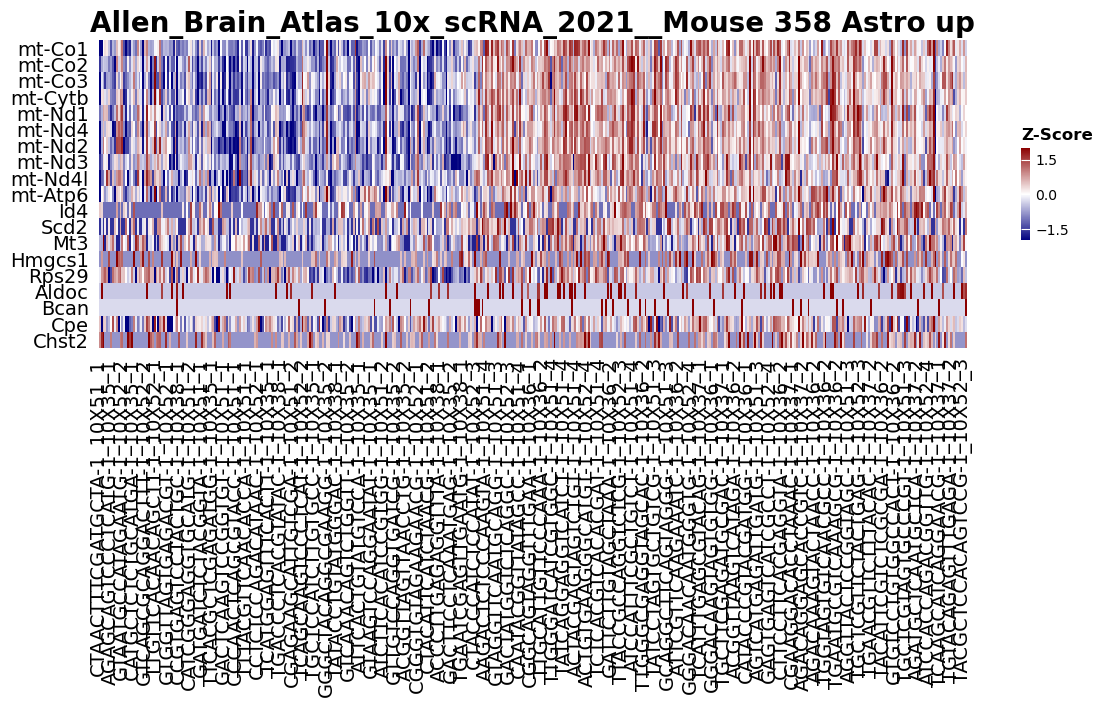

In [127]:
# plotting heatmap
i = 2
genes = res.res2d.Lead_genes[i].split(";")
# Make sure that ``ofname`` is not None, if you want to save your figure to disk
ax = heatmap(df = res.heatmat.loc[genes], z_score=0, title=terms[i], figsize=(14,4))